Mini-Batch Gradient Descent differs from the classic one, in that that not the entirety of the data gets fed into the model at once. Instead we define a batch size, and for each epoch we feed the whole data chunk by chunk, updating params after each chunk. This has benefits such as: smaller sample size -> a bit noiser results -> less prone to overfitting, more memory efficiency, chance of getting unstuck from local minima. We use TensorDataset and DataLoader for batching in pytorch.

In [ ]:
import torch
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
X = torch.linspace(-3, 3, 300).reshape(-1, 1)
y = torch.sin(X) + torch.randn(300, 1) * 0.15

indices = torch.randperm(300) # Shuffle the indices

# Split up into train/val/test sets
X_train, y_train = X[indices[:210]], y[indices[:210]]
X_val, y_val = X[indices[210:255]], y[indices[210:255]]
X_test, y_test = X[indices[255:]], y[indices[255:]]


batch_size = 32 # How many data points get fed into the model on each step
num_epochs = 500

model = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
)

opt = optim.Adam(model.parameters(), lr=0.01)
loss_ft = nn.MSELoss()

# Create Tensor dataset obj
train_dataset = TensorDataset(X_train, y_train)

# Create the loader, that splits data into batches and feeds into the model
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:

      # Train on batch with backward
      pred = model(X_batch)
      loss_train = loss_ft(pred, y_batch)
      loss_train.backward()
      opt.step()
      opt.zero_grad()

    # Test out on validation set
    with torch.no_grad():
        pred_val = model(X_val)
        loss_val = loss_ft(pred_val, y_val)

    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())

    if epoch % (num_epochs / 10) == 0 or epoch == (num_epochs - 1):
      print(f'Epoch {epoch}')
      print(f'Training set loss: {loss_train:.4f}')
      print(f'Validation set loss: {loss_val:.4f}')


Epoch 0
Training set loss: 0.2228
Validation set loss: 0.1625
Epoch 50
Training set loss: 0.0156
Validation set loss: 0.0339
Epoch 100
Training set loss: 0.0197
Validation set loss: 0.0280
Epoch 150
Training set loss: 0.0311
Validation set loss: 0.0233
Epoch 200
Training set loss: 0.0220
Validation set loss: 0.0251
Epoch 250
Training set loss: 0.0269
Validation set loss: 0.0249
Epoch 300
Training set loss: 0.0353
Validation set loss: 0.0302
Epoch 350
Training set loss: 0.0208
Validation set loss: 0.0224
Epoch 400
Training set loss: 0.0321
Validation set loss: 0.0199
Epoch 450
Training set loss: 0.0254
Validation set loss: 0.0222
Epoch 499
Training set loss: 0.0345
Validation set loss: 0.0203


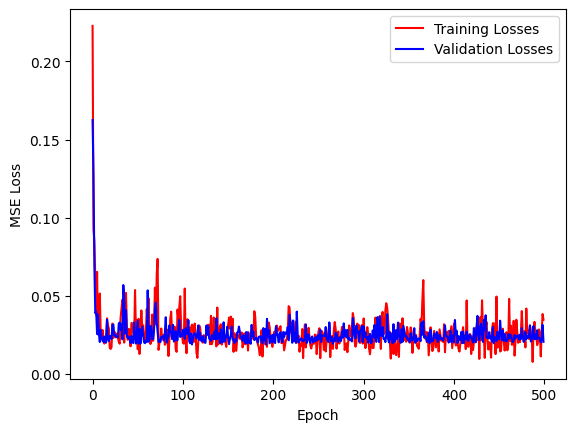

In [ ]:
plt.plot(train_losses, color='red', label='Training Losses')
plt.plot(val_losses, color='blue', label='Validation Losses')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()